In [1]:
import pandas as pd
import cnsplots as cns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg
import cairosvg
import tempfile
import numpy as np
import seaborn as sns
from pathlib import Path
from matplotlib.colors import to_rgb, to_hex
from collections import defaultdict
import os
from openTSNE import TSNE
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# define constants
COLNAME = "assigned_subcat" # hierarchy level to be analyzed, from here on defined as 'subcategory'
COLNAME_MAP = "Subcategory" # respective column name in the mapping file
TOP_COLNAME = "assigned_top" # hierarchy level to serve as top-level category/mapping
TOP_COLNAME_MAP = "Top_Category" # respective column name in the mapping file
SEQ_ID = 0.95 # sequence identity threshold used for clustering (part of input data file name)

# assertions
assert COLNAME and TOP_COLNAME in ["assigned_subcat", "assigned_cat", "assigned_top"], "Invalid column name. Must be one of 'assigned_subcat', 'assigned_cat', or 'assigned_top'."
assert COLNAME_MAP and TOP_COLNAME_MAP in ["Subcategory", "Category", "Top_Category"], "Invalid column name. Must be one of 'Subcategory', 'Category', or 'Top_Category'."
assert SEQ_ID in [0.95, 0.2], "Invalid sequence identity threshold. Must be one of 0.95, 0.2."

In [3]:
#######################
# plotting utilities 
#######################

# define colors for top-level categories
topcat_colors = {
    "Assembly": "#007BFF",
    "Structural": "#1e00ff",
    "Host takeover": "#2fff00",
    "NA processing": "#00ffb7",
    "Replication":"#00d9ff",
    "Translation": "#f6ff00",
    "AMGs": "#ffbf00", #"#ffa200",
    "Lysis": "#ff0000", 
    "Anti-Defense": "#ff00dd", 
    "Effectors": "#8e01f9", 
    "Lysogeny": "#FF5A00", #"#ff007b",
    "Unknown": "#bdbdbd", 
}

# define colors for mid-level categories
cat_colors = {
    "Transcriptional regulation": "#2fff00",
    "Transcriptional inhibition": "#02d136",
    "Host resource takeover": "#39fa69",
    "Transcriptional antitermination": "#60c006",
    "Host takeover via phosphorylation": "#3ea52e", 
    "Lytic switch": "#74d216",
    "Transcription factor": "#3C6D0F",
    "Transcriptional machinery": "#0D6806",

    "Integration": "#00ffb7",
    "Excision and transcriptional regulation": "#0dd09c",
    "DNA repair": "#0D916D",
    "Recombination": "#036D51",
    "RNA modification": "#71F8D4",
    "RNA cleavage": "#37F9AF",
    "RNA sealing": "#14AC72",

    "Maintenance": "#FF5A00", #"#ff007b",

    "Protein synthesis": "#f4fa51",
    "Ribosomal protein": "#f3fb00",
    "Translation regulation": "#d0d703",
    "Ribosome biogenesis": "#a0a512",
    "Protein maturation and folding": "#FFFF00",

    "Head morphogenesis": "#4099F9",
    "Head-to-tail joining": "#74B7FE",
    "Tail assembly": "#0F559F",
    "Baseplate assembly": "#014894",
    "DNA packaging": "#0E437B",

    "Replication initiation":"#00d9ff",
    "DNA replication":"#3AAEC3",

    "Capsid": "#1e00ff",
    "DNA injection": "#1903c1",
    "Tail and Fibers": "#553ffb",
    "Baseplate": "#3c2dad",

    "Host polysaccharide degradation": "#e24141", 
    "Endolysin": "#ff0000", 
    "Spanin": "#a90202", 
    "Lysis regulation": "#7D1C1C", 

    "Anti-Restriction": "#ff00dd", 
    "Anti-TA": "#e634f6", 
    "Anti-Defense": "#df00fd",

    "Nucleotide metabolism": "#ffbf00",
    "Other AMGs": "#ff9100",

    "Virulence factors": "#af01f9", 
    "Stress response and damage protection": "#7d01f9", 
    "Membrane transport and signaling": "#a312c3", 
    "Superinfection exclusion": "#710589", 

    "Unknown": "#bdbdbd", 
}


def adjust_color(color, factor=0.2, lighten=True):
    """Mix a color with white or black. The closer the value to 1, the more white/black contained"""
    r, g, b = to_rgb(color)

    if lighten:
        r = r + (1-r)*factor
        g = g + (1-g)*factor
        b = b + (1-b)*factor
    else:
        r = r * (1-factor)
        g = g * (1-factor)
        b = b * (1-factor)

    return to_hex((r, g, b))


def get_factor_range(n, min_n=2, max_n=20, min_spread=0.1, max_spread=0.5):
    """Returns factor range depending on n"""
    # normalize n to 0-1
    t = min(1, max(0, (n - min_n) / (max_n - min_n)))

    spread = min_spread + t * (max_spread - min_spread)

    base = 0.15 
    return base, base+spread


def generate_subcategory_colors(topcat_colors, cat_to_top):
    """Generate colors for subcategories based on their top-level category colors."""
    top_to_sub = defaultdict(list)
    for sub, top in cat_to_top.items():
        top_to_sub[top].append(sub)

    sub_colors = {}

    for top, subs in top_to_sub.items():
        base_color = topcat_colors.get(top, "#999999")
        n = len(subs)

        low, high = get_factor_range(n)

        if n == 1:
            factors = [0.2]
        else:
            factors = np.linspace(low, high, n)

        for i, (sub, factor) in enumerate(zip(subs, factors)):
            lighten = (i % 2 == 0) # alternate
            sub_colors[sub] = adjust_color(base_color, factor, lighten)

    return sub_colors

# lighten top-level category colors
topcat_colors_adjusted = {
    k: adjust_color(v, factor=0.2, lighten=True)
    for k, v in topcat_colors.items()
}

In [4]:
#######################
# Panel B: barplot PhageOnly
#######################

# read mapping file for keywords to sub-, mid-, and top-level categories
keywords_map = pd.read_csv("./input_data/Category_map.csv") 

# create a mapping from subcategories to top-level categories
cat_to_top = keywords_map[[COLNAME_MAP, TOP_COLNAME_MAP]].drop_duplicates().set_index(COLNAME_MAP)[TOP_COLNAME_MAP].to_dict()

def clean_df(df, colname):
    """"Helper function to clean the dataframe by replacing entries with semicolons in the specified column with 'Unknown'."""
    mask = df[colname].str.contains(";")
    df.loc[mask, colname] = "Unknown"
    return df

# read in dataframe and clean it
phage_repr = pd.read_csv(f"./input_data/PhageOnly_new_representatives_assigned_cat_{SEQ_ID}.tsv", sep="\t") # only phage representatives
phage_repr = clean_df(phage_repr, COLNAME)

# get counts of subcategories, excluding "Unknown"
phage_counts = phage_repr[COLNAME].value_counts()

def counts_to_df(vc):
    """Helper function to convert a value counts series to a dataframe."""
    return vc.rename("count").reset_index().rename(columns={"index": COLNAME})

# convert counts to dataframe
df_phage_counts = counts_to_df(phage_counts)

# map subcategories to top-level categories
if COLNAME != "assigned_top":
    df_phage_counts[TOP_COLNAME] = df_phage_counts[COLNAME].map(cat_to_top)
else: 
    df_phage_counts[TOP_COLNAME] = df_phage_counts[COLNAME]

# exclude Unknowns for further analysis
df_phage_counts = df_phage_counts[df_phage_counts[COLNAME] != "Unknown"]

# map subcategories to top-level categories and aggregate counts
df_phage_top_mapped = (
    df_phage_counts.groupby(TOP_COLNAME, as_index=False)["count"]
      .sum()
      .sort_values("count", ascending=False)
)

In [5]:
#######################
# Panel C: barplot Augmented-Dataset
#######################

# read in dataframe and clean it
all_repr = pd.read_csv(f"./input_data/all_new_representatives_assigned_cat_{SEQ_ID}.tsv", sep="\t") # all representatives, including phages, bacteria, and viruses
all_repr = clean_df(all_repr, COLNAME)

# get counts of subcategories, excluding "Unknown"
data_counts = all_repr[COLNAME].value_counts()

def counts_to_df(vc):
    """Helper function to convert a value counts series to a dataframe."""
    return vc.rename("count").reset_index().rename(columns={"index": COLNAME})

# convert counts to dataframe
df_counts = counts_to_df(data_counts)

# map subcategories to top-level categories
if COLNAME != "assigned_top":
    df_counts[TOP_COLNAME] = df_counts[COLNAME].map(cat_to_top)
else: 
    df_counts[TOP_COLNAME] = df_counts[COLNAME]

# exclude Unknowns for further analysis
df_counts = df_counts[df_counts[COLNAME] != "Unknown"]

# map subcategories to top-level categories and aggregate counts
df_top_mapped = (
    df_counts.groupby(TOP_COLNAME, as_index=False)["count"]
      .sum()
      .sort_values("count", ascending=False)
)

In [6]:
#######################
# Panel D: barplot Augmented-Dataset sub-level
#######################
if TOP_COLNAME == "assigned_cat":
    coloring = cat_colors

if TOP_COLNAME == "assigned_top":
    coloring = topcat_colors

# generate colors for subcategories based on their top-level category colors
subcat_colors = generate_subcategory_colors(coloring, cat_to_top)  

facet_order = ["NA processing", "Host takeover", "Assembly", "Structural", "Replication", "Lysis", "Lysogeny", "Translation", "Anti-Defense", "AMGs", "Effectors"]

df_counts[TOP_COLNAME] = pd.Categorical(df_counts[TOP_COLNAME], categories=facet_order, ordered=True)


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

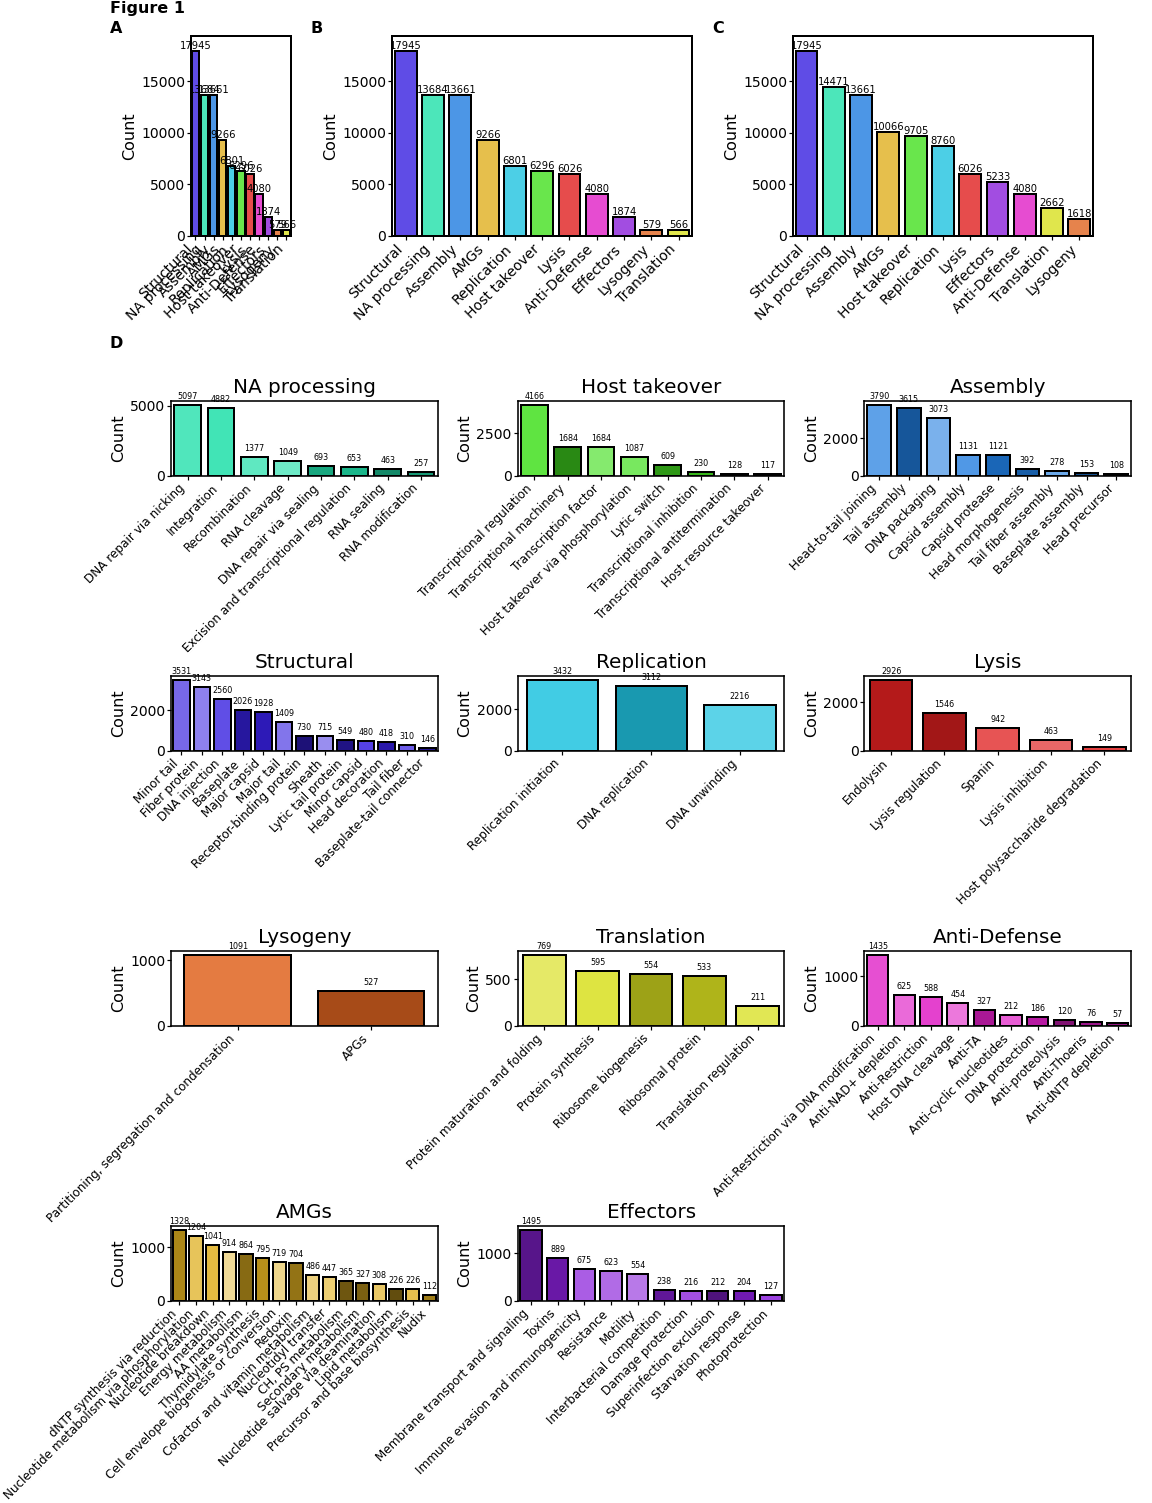

In [7]:
cns.settings.title_fontweight = "normal"
mp = cns.multipanel(
    max_width=600, title="Figure 1", title_fontweight="bold", loc="left"
)

######################
# Panel A: Schematic representation of classification approach
mp.panel("A", 50, 100)
ax = cns.barplot(
    data=df_phage_top_mapped, x=TOP_COLNAME, y="count", palette=topcat_colors_adjusted, hue=TOP_COLNAME, legend=False, errorbar=None, edgecolor="black"
)
# customize axes
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.xlabel("")

for p in ax.patches:
    height = p.get_height()

    if height == 0:
        continue

    x = p.get_x() + p.get_width() / 2
    ax.text(x, height, f"{int(height)}", ha="center", va="bottom", fontsize=5)

ymax = df_phage_top_mapped["count"].max()
ax.set_ylim(0, ymax * 1.08)

ax.set_title("")

######################
# Panel B: PhageOnly-Dataset subcategory counts aggregated at the top level
mp.panel("B", 150, 100)
ax = cns.barplot(
    data=df_phage_top_mapped, x=TOP_COLNAME, y="count", palette=topcat_colors_adjusted, hue=TOP_COLNAME, legend=False, errorbar=None, edgecolor="black"
)
# customize axes
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.xlabel("")

for p in ax.patches:
    height = p.get_height()

    if height == 0:
        continue

    x = p.get_x() + p.get_width() / 2
    ax.text(x, height, f"{int(height)}", ha="center", va="bottom", fontsize=5)

ymax = df_phage_top_mapped["count"].max()
ax.set_ylim(0, ymax * 1.08)

ax.set_title("")

######################
# Panel C: Augmented-Dataset subcategory counts aggregated at the top level
mp.panel("C", 150, 100)
ax = cns.barplot(
    data=df_top_mapped, x=TOP_COLNAME, y="count", palette=topcat_colors_adjusted, hue=TOP_COLNAME, legend=False, errorbar=None, edgecolor="black"
)
# customize axes
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.xlabel("")

for p in ax.patches:
    height = p.get_height()

    if height == 0:
        continue

    x = p.get_x() + p.get_width() / 2
    ax.text(x, height, f"{int(height)}", ha="center", va="bottom", fontsize=5)

ymax = df_top_mapped["count"].max()
ax.set_ylim(0, ymax * 1.08)

ax.set_title("")

######################
# Panel D: Augmented-Dataset subcategory counts
mp.panel("D", 500, 500, margin_top=40)
ax = plt.gca()

# Hide the outer Panel D axis
ax.set_axis_off()

ncols = 3
nrows = int(np.ceil(len(facet_order) / ncols))

# spacing of the facet axes inside Panel D
left = 0.02
bottom = 0.05
right = 0.02
top = 0.05
hspace = 0.2
wspace = 0.08

facet_width = (1 - left - right - (ncols - 1) * wspace) / ncols
facet_height = (1 - bottom - top - (nrows - 1) * hspace) / nrows

for i, topcat in enumerate(facet_order):
    row = i // ncols
    col = i % ncols

    x = left + col * (facet_width + wspace)
    y = 1 - top - (row + 1) * facet_height - row * hspace

    facet_ax = ax.inset_axes([x, y, facet_width, facet_height])

    # data for this top category
    subset = df_counts[df_counts[TOP_COLNAME] == topcat]

    sns.barplot(data=subset, x=COLNAME, y="count", hue=COLNAME, dodge=False, errorbar=None,
        edgecolor="black", palette=subcat_colors, legend=False, ax=facet_ax)

    facet_ax.set_title(topcat, fontsize=10)
    facet_ax.set_xlabel("")
    facet_ax.set_ylabel("Count")

    facet_ax.tick_params(axis="x", labelrotation=45, labelsize=6)

    for label in facet_ax.get_xticklabels():
        label.set_horizontalalignment("right")

    # annotations
    if COLNAME == "assigned_subcat":
        for container in facet_ax.containers:
            facet_ax.bar_label(container, fmt="%d", padding=2, fontsize=4)

    else:
        for p in facet_ax.patches:
            height = p.get_height()

            if height == 0:
                continue

            x_text = p.get_x() + p.get_width() / 2

            # Get corresponding x-axis label
            tick_index = int(round(p.get_x()))
            labels = facet_ax.get_xticklabels()

            if tick_index < len(labels):
                label = labels[tick_index].get_text()
            else:
                label = ""

            if label == "Maintenance":
                facet_ax.text(x_text, height * 0.5, f"{int(height)}", ha="center", va="center", fontsize=8)
            else:
                facet_ax.text(x_text, height, f"{int(height)}", ha="center", va="bottom", fontsize=8)

    # borders
    for spine in facet_ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

# Save final figure
outdir = Path("./plots/")
outdir.mkdir(parents=True, exist_ok=True)
cns.savefig(outdir / "FigureS1.svg")